# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** [Bily Steven Nathanael]
- **Email:** [bily.nathanael1@gmail.com]
- **ID Dicoding:** [CDC348D6Y1384]

## Menentukan Pertanyaan Bisnis

Dataset Bike Sharing merekam data peminjaman sepeda harian dan per jam dari sistem Capital Bikeshare di Washington D.C., Amerika Serikat selama tahun 2011–2012. Dataset ini mencakup informasi cuaca, musim, hari kerja, dan jenis pengguna (kasual vs. terdaftar).

Berdasarkan eksplorasi awal terhadap dataset, berikut adalah pertanyaan bisnis yang ingin dijawab:

- **Pertanyaan 1:** Pada kondisi cuaca dan musim seperti apa jumlah peminjaman sepeda harian mencapai puncak tertinggi dan titik terendahnya?
- **Pertanyaan 2:** Pada jam berapa pengguna kasual dan pengguna terdaftar paling aktif meminjam sepeda, dan apakah pola tersebut berbeda antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan umum
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## Data Wrangling

### Gathering Data

Pada tahap ini kita memuat dua file dataset utama:
- `day.csv` : data agregat harian (731 baris)
- `hour.csv` : data agregat per jam (17.379 baris)

Kedua file ini merupakan bagian dari Bike Sharing Dataset yang bersumber dari sistem Capital Bikeshare, Washington D.C., tahun 2011–2012.

In [14]:
# Load dataset
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

print('=== day.csv ===')
print(f'Jumlah baris: {day_df.shape[0]}, Jumlah kolom: {day_df.shape[1]}')
display(day_df.head())

print('\n=== hour.csv ===')
print(f'Jumlah baris: {hour_df.shape[0]}, Jumlah kolom: {hour_df.shape[1]}')
display(hour_df.head())

=== day.csv ===
Jumlah baris: 731, Jumlah kolom: 16


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



=== hour.csv ===
Jumlah baris: 17379, Jumlah kolom: 17


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset `day.csv` berisi 731 baris yang merepresentasikan setiap hari selama dua tahun (2011-2012) dengan 16 kolom atribut.
- Dataset `hour.csv` berisi 17.379 baris dengan granularitas per jam dan memiliki satu kolom tambahan yaitu `hr` (jam) dibandingkan `day.csv`.
- Kedua dataset sudah tersusun rapi dengan urutan kronologis dari tanggal 1 Januari 2011.

### Assessing Data

Pada tahap ini kita memeriksa kualitas data meliputi:
1. Tipe data tiap kolom
2. Nilai yang hilang (missing values)
3. Data duplikat
4. Statistik deskriptif dasar

In [15]:
print('=== Tipe Data day_df ===')
print(day_df.dtypes)

print('\n=== Missing Values day_df ===')
print(day_df.isnull().sum())

print('\n=== Duplikat day_df ===')
print(f'Jumlah duplikat: {day_df.duplicated().sum()}')

print('\n=== Statistik Deskriptif day_df ===')
display(day_df.describe())

=== Tipe Data day_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Missing Values day_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Duplikat day_df ===
Jumlah duplikat: 0

=== Statistik Deskriptif day_df ===


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [16]:
print('=== Tipe Data hour_df ===')
print(hour_df.dtypes)

print('\n=== Missing Values hour_df ===')
print(hour_df.isnull().sum())

print('\n=== Duplikat hour_df ===')
print(f'Jumlah duplikat: {hour_df.duplicated().sum()}')

print('\n=== Statistik Deskriptif hour_df ===')
display(hour_df.describe())

=== Tipe Data hour_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Missing Values hour_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Duplikat hour_df ===
Jumlah duplikat: 0

=== Statistik Deskriptif hour_df ===


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan missing values pada kedua dataset — data lengkap dan tidak perlu imputasi.
- Tidak ditemukan duplikat pada kedua dataset.
- Kolom `dteday` masih bertipe object (string), perlu dikonversi ke tipe datetime.
- Kolom kategorikal seperti `season`, `weathersit`, `weekday` tersimpan sebagai integer — perlu dipetakan ke label yang lebih informatif untuk visualisasi.
- Nilai `temp`, `atemp`, `hum`, dan `windspeed` dalam bentuk ternormalisasi (0-1), perlu denormalisasi untuk nilai aktual.

### Cleaning Data

Berdasarkan hasil assessment, langkah pembersihan yang perlu dilakukan:
1. Konversi kolom `dteday` dari string ke datetime
2. Pemetaan kolom kategorikal ke label yang informatif
3. Denormalisasi nilai suhu, kelembaban, dan kecepatan angin ke satuan aslinya

In [17]:
def clean_bike_df(df):
    df = df.copy()

    # 1. Konversi tanggal
    df['dteday'] = pd.to_datetime(df['dteday'])

    # 2. Pemetaan label kategorikal
    season_map  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    weather_map = {
        1: 'Clear/Partly Cloudy',
        2: 'Mist/Cloudy',
        3: 'Light Rain/Snow',
        4: 'Heavy Rain/Snow'
    }
    weekday_map = {0:'Sunday',1:'Monday',2:'Tuesday',
                   3:'Wednesday',4:'Thursday',5:'Friday',6:'Saturday'}
    yr_map = {0: 2011, 1: 2012}

    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)
    df['year']          = df['yr'].map(yr_map)

    # 3. Denormalisasi nilai cuaca ke satuan asli
    df['temp_c']        = df['temp'] * 41
    df['atemp_c']       = df['atemp'] * 50
    df['hum_pct']       = df['hum'] * 100
    df['windspeed_kph'] = df['windspeed'] * 67

    return df

day_df  = clean_bike_df(day_df)
hour_df = clean_bike_df(hour_df)

print('Cleaning selesai!')
display(day_df[['dteday','season_label','weather_label','weekday_label','year',
                'temp_c','hum_pct','windspeed_kph','cnt']].head())

Cleaning selesai!


,dteday,season_label,weather_label,weekday_label,year,temp_c,hum_pct,windspeed_kph,cnt
0,2011-01-01,Spring,Mist/Cloudy,Saturday,2011,14.110847,80.5833,10.749882,985
1,2011-01-02,Spring,Mist/Cloudy,Sunday,2011,14.902598,69.6087,16.652113,801
2,2011-01-03,Spring,Clear/Partly Cloudy,Monday,2011,8.050924,43.7273,16.636703,1349
3,2011-01-04,Spring,Clear/Partly Cloudy,Tuesday,2011,8.200000,59.0435,10.739832,1562
4,2011-01-05,Spring,Clear/Partly Cloudy,Wednesday,2011,9.305237,43.6957,12.522300,1600


**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe datetime, memungkinkan analisis berbasis waktu.
- Label kategorikal baru (`season_label`, `weather_label`, `weekday_label`) membuat data lebih mudah dibaca dan divisualisasikan.
- Nilai suhu, kelembaban, dan kecepatan angin kini dalam satuan yang intuitif: Celsius, persen, dan km/h.
- Tidak ada baris yang hilang setelah proses cleaning — integritas data terjaga.

## Exploratory Data Analysis (EDA)

### Explore Distribusi Peminjaman Harian

Sebelum menjawab pertanyaan bisnis, kita perlu memahami distribusi umum jumlah peminjaman sepeda harian (`cnt`) untuk mendapatkan gambaran awal tentang pola datanya.

In [18]:
print('=== Statistik Peminjaman Harian (cnt) ===')
print(day_df['cnt'].describe().round(2))

print('\n=== Hari dengan Peminjaman Tertinggi ===')
display(day_df.nlargest(5, 'cnt')[['dteday','season_label','weather_label','temp_c','cnt']])

print('\n=== Hari dengan Peminjaman Terendah ===')
display(day_df.nsmallest(5, 'cnt')[['dteday','season_label','weather_label','temp_c','cnt']])

=== Statistik Peminjaman Harian (cnt) ===
count     731.00
mean     4504.35
std      1937.21
min        22.00
25%      3152.00
50%      4548.00
75%      5956.00
max      8714.00
Name: cnt, dtype: float64

=== Hari dengan Peminjaman Tertinggi ===


,dteday,season_label,weather_label,temp_c,cnt
623,2012-09-15,Fall,Clear/Partly Cloudy,24.941653,8714
637,2012-09-29,Winter,Clear/Partly Cloudy,22.242500,8555
630,2012-09-22,Fall,Clear/Partly Cloudy,26.650000,8395
447,2012-03-23,Summer,Mist/Cloudy,24.668347,8362
504,2012-05-19,Summer,Clear/Partly Cloudy,24.600000,8294



=== Hari dengan Peminjaman Terendah ===


,dteday,season_label,weather_label,temp_c,cnt
667,2012-10-29,Winter,Light Rain/Snow,18.040000,22
26,2011-01-27,Spring,Clear/Partly Cloudy,7.995000,431
725,2012-12-26,Spring,Light Rain/Snow,9.976653,441
25,2011-01-26,Spring,Light Rain/Snow,8.917500,506
64,2011-03-06,Spring,Mist/Cloudy,15.437402,605


**Insight:**
- Rata-rata peminjaman harian sekitar 4.504 sepeda, dengan nilai maksimum 8.714 dan minimum hanya 22.
- Hari-hari dengan peminjaman tertinggi cenderung terjadi pada musim panas/gugur dengan cuaca cerah.
- Hari-hari dengan peminjaman terendah berkaitan dengan cuaca ekstrem atau awal tahun 2011 saat sistem masih baru.

### Explore Pengaruh Musim dan Cuaca

Eksplorasi ini bertujuan melihat rata-rata peminjaman berdasarkan kombinasi musim dan kondisi cuaca, sebagai dasar untuk menjawab Pertanyaan 1.

In [19]:
season_avg = day_df.groupby('season_label')['cnt'].agg(['mean','min','max']).round(0)
season_avg.columns = ['Rata-rata', 'Minimum', 'Maksimum']
print('=== Peminjaman per Musim ===')
display(season_avg.sort_values('Rata-rata', ascending=False))

weather_avg = day_df.groupby('weather_label')['cnt'].agg(['mean','min','max']).round(0)
weather_avg.columns = ['Rata-rata', 'Minimum', 'Maksimum']
print('\n=== Peminjaman per Kondisi Cuaca ===')
display(weather_avg.sort_values('Rata-rata', ascending=False))

combo = day_df.groupby(['season_label','weather_label'])['cnt'].mean().round(0).unstack()
print('\n=== Rata-rata Peminjaman: Musim x Cuaca ===')
display(combo)

=== Peminjaman per Musim ===


,Rata-rata,Minimum,Maksimum
season_label,,,
Fall,5644.0,1115,8714
Summer,4992.0,795,8362
Winter,4728.0,22,8555
Spring,2604.0,431,7836



=== Peminjaman per Kondisi Cuaca ===


,Rata-rata,Minimum,Maksimum
weather_label,,,
Clear/Partly Cloudy,4877.0,431,8714
Mist/Cloudy,4036.0,605,8362
Light Rain/Snow,1803.0,22,4639



=== Rata-rata Peminjaman: Musim x Cuaca ===


weather_label,Clear/Partly Cloudy,Light Rain/Snow,Mist/Cloudy
season_label,,,
Fall,5878.0,2752.0,5222.0
Spring,2811.0,935.0,2357.0
Summer,5549.0,1169.0,4237.0
Winter,5044.0,1962.0,4654.0


**Insight:**
- Musim gugur (Fall) memiliki rata-rata peminjaman tertinggi, diikuti musim panas (Summer) dan dingin (Winter), sedangkan musim semi (Spring) paling rendah.
- Cuaca cerah menghasilkan peminjaman jauh lebih tinggi dibandingkan kondisi berawan atau hujan.
- Kombinasi terburuk adalah cuaca hujan/salju di musim semi — menghasilkan jumlah peminjaman paling sedikit.

### Explore Pola Per Jam Pengguna Kasual vs. Terdaftar

Eksplorasi ini melihat bagaimana pola peminjaman per jam berbeda antara pengguna kasual dan terdaftar, serta apakah ada perbedaan antara hari kerja dan hari libur — sebagai dasar untuk menjawab Pertanyaan 2.

In [20]:
hourly_avg  = hour_df.groupby('hr')[['casual','registered']].mean().round(2)
workday_hour = hour_df[hour_df['workingday'] == 1].groupby('hr')[['casual','registered']].mean().round(2)
holiday_hour = hour_df[hour_df['workingday'] == 0].groupby('hr')[['casual','registered']].mean().round(2)

print('=== Jam Puncak (Semua Hari) ===')
print(f'Kasual    : {hourly_avg["casual"].idxmax():02d}:00')
print(f'Terdaftar : {hourly_avg["registered"].idxmax():02d}:00')

print('\n=== Jam Puncak Hari Kerja ===')
print(f'Kasual    : {workday_hour["casual"].idxmax():02d}:00')
print(f'Terdaftar : {workday_hour["registered"].idxmax():02d}:00')

print('\n=== Jam Puncak Hari Libur ===')
print(f'Kasual    : {holiday_hour["casual"].idxmax():02d}:00')
print(f'Terdaftar : {holiday_hour["registered"].idxmax():02d}:00')

=== Jam Puncak (Semua Hari) ===
Kasual    : 14:00
Terdaftar : 17:00

=== Jam Puncak Hari Kerja ===
Kasual    : 17:00
Terdaftar : 17:00

=== Jam Puncak Hari Libur ===
Kasual    : 14:00
Terdaftar : 12:00


**Insight:**
- Pengguna terdaftar pada hari kerja memiliki dua puncak aktivitas: pagi (sekitar 08:00) dan sore (sekitar 17:00) — pola komuter.
- Pengguna kasual lebih aktif pada siang hari tanpa pola komuter yang jelas.
- Di hari libur, pola pengguna terdaftar bergeser menyerupai pengguna kasual — puncak tunggal di siang hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada kondisi cuaca dan musim seperti apa jumlah peminjaman sepeda harian mencapai puncak tertinggi dan titik terendahnya?

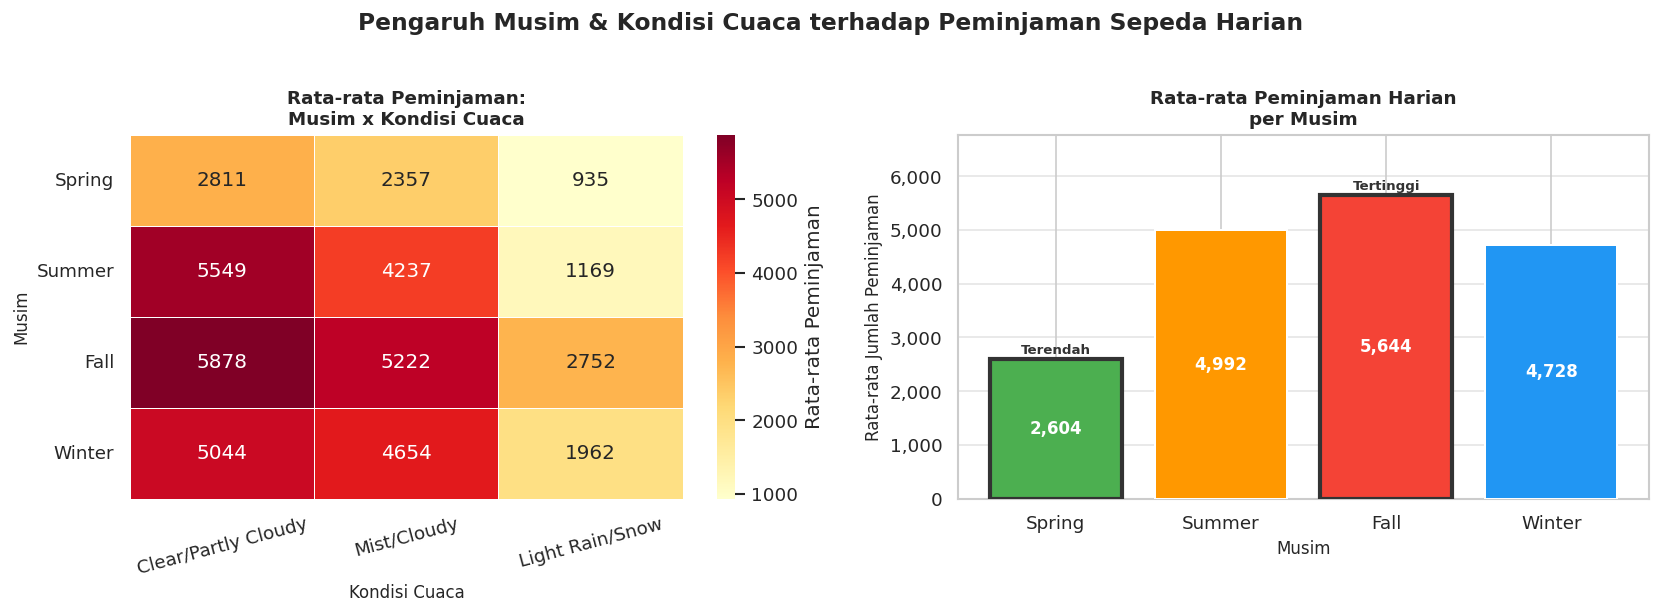

Visualisasi Pertanyaan 1 tersimpan.


In [21]:
season_order  = ['Spring', 'Summer', 'Fall', 'Winter']
weather_order = ['Clear/Partly Cloudy', 'Mist/Cloudy', 'Light Rain/Snow']

day_filtered = day_df[day_df['weather_label'].isin(weather_order)].copy()

heatmap_data = day_filtered.groupby(['season_label','weather_label'])['cnt'].mean().unstack()
heatmap_data = heatmap_data.reindex(index=season_order, columns=weather_order)

season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','max','min']).reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pengaruh Musim & Kondisi Cuaca terhadap Peminjaman Sepeda Harian',
             fontsize=14, fontweight='bold', y=1.02)

# Panel kiri: Heatmap
ax1 = axes[0]
sns.heatmap(heatmap_data, ax=ax1, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Rata-rata Peminjaman'})
ax1.set_title('Rata-rata Peminjaman:\nMusim x Kondisi Cuaca', fontsize=11, fontweight='bold')
ax1.set_xlabel('Kondisi Cuaca', fontsize=10)
ax1.set_ylabel('Musim', fontsize=10)
ax1.tick_params(axis='x', rotation=15)
ax1.tick_params(axis='y', rotation=0)

# Panel kanan: Bar chart
ax2 = axes[1]
colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']
bars = ax2.bar(season_order, season_stats['mean'], color=colors, edgecolor='white', linewidth=1.2, zorder=3)

max_idx = season_stats['mean'].idxmax()
min_idx = season_stats['mean'].idxmin()
for season, bar in zip(season_order, bars):
    if season == max_idx:
        bar.set_edgecolor('#333')
        bar.set_linewidth(2.5)
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 'Tertinggi', ha='center', fontsize=8, color='#333', fontweight='bold')
    if season == min_idx:
        bar.set_edgecolor('#333')
        bar.set_linewidth(2.5)
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 'Terendah', ha='center', fontsize=8, color='#333', fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'{season_stats["mean"][season]:,.0f}', ha='center', va='center',
             fontsize=10, color='white', fontweight='bold')

ax2.set_title('Rata-rata Peminjaman Harian\nper Musim', fontsize=11, fontweight='bold')
ax2.set_xlabel('Musim', fontsize=10)
ax2.set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.set_ylim(0, season_stats['mean'].max() * 1.2)
ax2.grid(axis='y', alpha=0.5, zorder=0)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Pertanyaan 1 tersimpan.')

**Insight Pertanyaan 1:**
- Peminjaman sepeda harian mencapai **puncak tertinggi** pada musim **Fall (Gugur)** dengan kondisi cuaca **cerah/sebagian berawan**, rata-rata lebih dari 5.600 peminjaman per hari.
- Peminjaman mencapai **titik terendah** pada musim **Spring (Semi)** dengan kondisi **hujan/salju ringan**, rata-rata di bawah 1.500 peminjaman per hari.
- Pola ini konsisten di semua musim: cuaca cerah selalu menghasilkan peminjaman lebih tinggi dibandingkan cuaca berawan atau hujan.
- Musim dingin (Winter) menghasilkan peminjaman lebih tinggi dari musim semi, kemungkinan karena sistem sepeda sudah lebih dikenal di tahun kedua (2012).

### Pertanyaan 2: Pada jam berapa pengguna kasual dan terdaftar paling aktif, dan apakah polanya berbeda di hari kerja vs. hari libur?

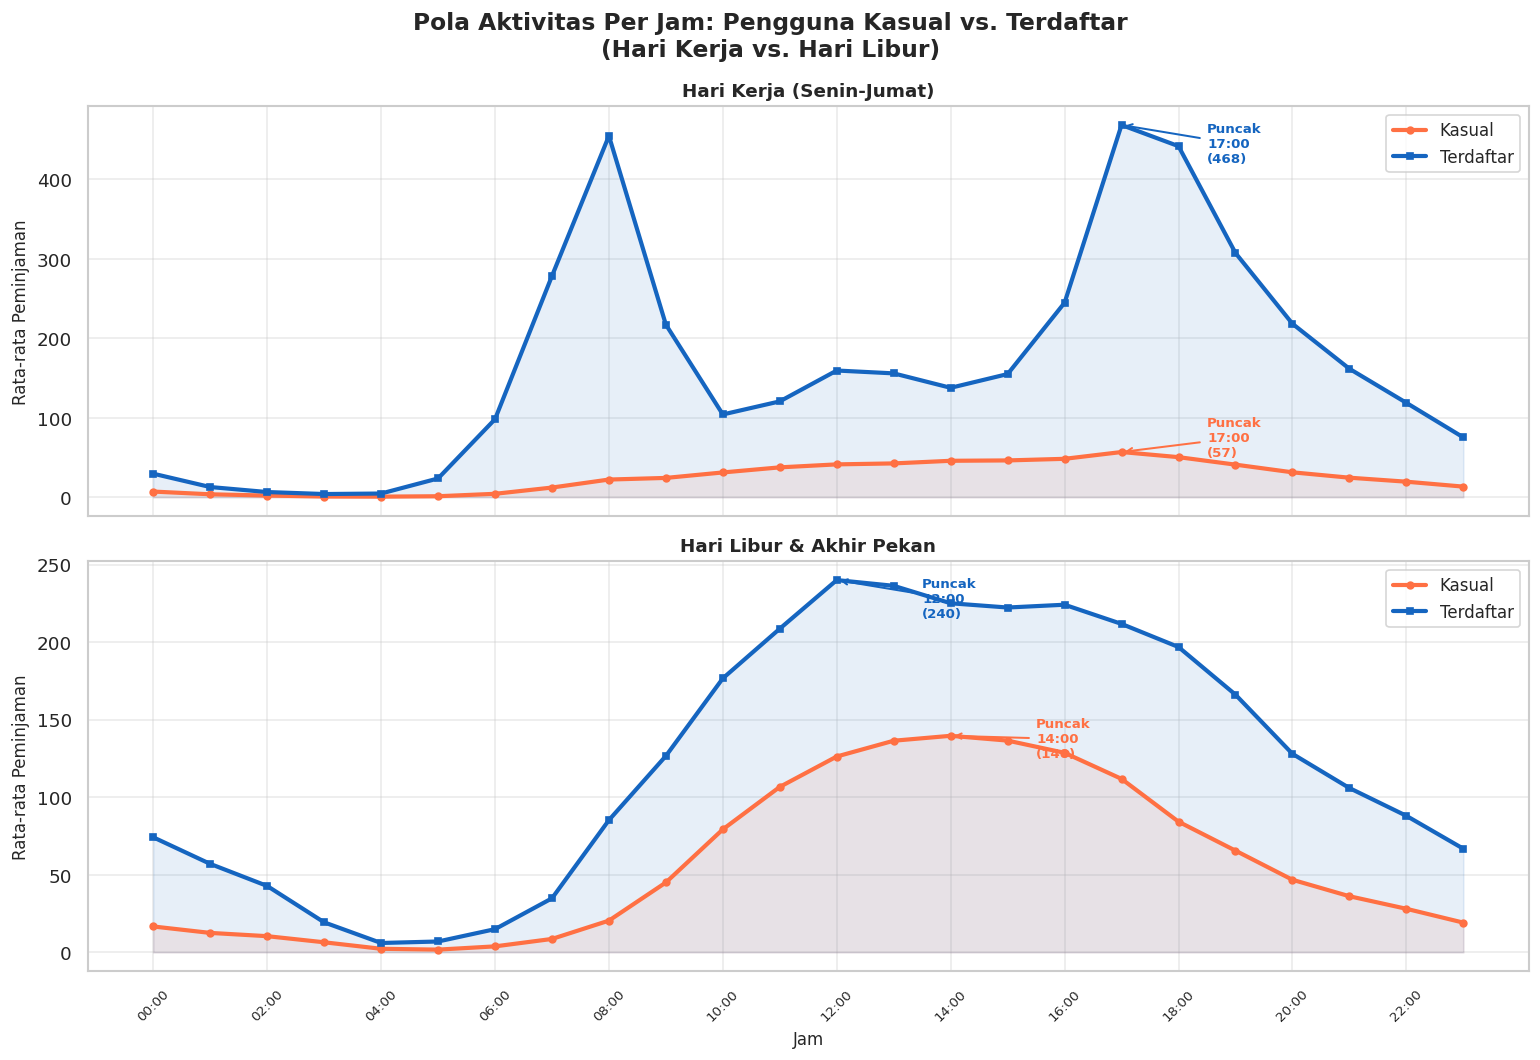

Visualisasi Pertanyaan 2 tersimpan.


In [22]:
workday = hour_df[hour_df['workingday'] == 1].groupby('hr')[['casual','registered']].mean()
holiday = hour_df[hour_df['workingday'] == 0].groupby('hr')[['casual','registered']].mean()

hours = list(range(24))
hour_labels = [f'{h:02d}:00' for h in hours]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Pola Aktivitas Per Jam: Pengguna Kasual vs. Terdaftar\n(Hari Kerja vs. Hari Libur)',
             fontsize=14, fontweight='bold')

def plot_hourly(ax, data, title):
    ax.plot(hours, data['casual'],     color='#FF7043', linewidth=2.5, marker='o', markersize=4, label='Kasual')
    ax.plot(hours, data['registered'], color='#1565C0', linewidth=2.5, marker='s', markersize=4, label='Terdaftar')
    for col, color in [('casual','#FF7043'), ('registered','#1565C0')]:
        peak_hr  = data[col].idxmax()
        peak_val = data[col].max()
        ax.annotate(f'Puncak\n{peak_hr:02d}:00\n({peak_val:.0f})',
                    xy=(peak_hr, peak_val),
                    xytext=(peak_hr + 1.5, peak_val * 0.90),
                    fontsize=8, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Rata-rata Peminjaman', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.4)
    ax.fill_between(hours, data['casual'],     alpha=0.10, color='#FF7043')
    ax.fill_between(hours, data['registered'], alpha=0.10, color='#1565C0')

plot_hourly(axes[0], workday, 'Hari Kerja (Senin-Jumat)')
plot_hourly(axes[1], holiday, 'Hari Libur & Akhir Pekan')

axes[1].set_xlabel('Jam', fontsize=10)
axes[1].set_xticks(hours[::2])
axes[1].set_xticklabels(hour_labels[::2], rotation=45, fontsize=8)

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Pertanyaan 2 tersimpan.')

**Insight Pertanyaan 2:**
- **Hari Kerja:** Pengguna terdaftar menunjukkan pola bimodal — lonjakan pertama sekitar pukul **08:00** dan lonjakan kedua sekitar pukul **17:00-18:00**, mencerminkan pola perjalanan komuter. Pengguna kasual relatif datar dengan puncak kecil di siang hari.
- **Hari Libur:** Pola pengguna terdaftar berubah menjadi puncak tunggal di siang hari (sekitar pukul **12:00-14:00**), serupa dengan pola pengguna kasual — menandakan penggunaan rekreatif.
- Pengguna kasual konsisten lebih aktif di siang hari terlepas dari jenis hari, menandakan mayoritas mereka adalah wisatawan atau pengguna non-rutin.

## Analisis Lanjutan: Clustering Berbasis Binning

Pada tahap ini kita menerapkan teknik **binning manual** untuk mengelompokkan hari-hari berdasarkan intensitas penggunaan sepeda. Tujuannya adalah memahami karakteristik hari-hari dengan penggunaan rendah, sedang, dan tinggi sehingga dapat memberikan rekomendasi operasional yang lebih tepat sasaran.

Pengelompokan dilakukan berdasarkan kuantil distribusi `cnt` harian:
- **Rendah**: cnt < Q1 (25th percentile)
- **Sedang**: Q1 <= cnt < Q3 (75th percentile)
- **Tinggi**: cnt >= Q3

In [23]:
q1 = day_df['cnt'].quantile(0.25)
q3 = day_df['cnt'].quantile(0.75)

def usage_cluster(cnt):
    if cnt < q1:
        return 'Rendah'
    elif cnt < q3:
        return 'Sedang'
    else:
        return 'Tinggi'

day_df['usage_cluster'] = day_df['cnt'].apply(usage_cluster)

print(f'Batas cluster — Rendah: < {q1:.0f} | Sedang: {q1:.0f}-{q3:.0f} | Tinggi: >= {q3:.0f}')
print('\nJumlah hari per cluster:')
print(day_df['usage_cluster'].value_counts())

cluster_profile = day_df.groupby('usage_cluster').agg(
    jumlah_hari=('cnt','count'),
    rata_peminjaman=('cnt','mean'),
    rata_suhu=('temp_c','mean'),
    rata_kelembaban=('hum_pct','mean'),
    rata_windspeed=('windspeed_kph','mean'),
    pct_hari_kerja=('workingday','mean')
).round(2)
cluster_profile['pct_hari_kerja'] = (cluster_profile['pct_hari_kerja'] * 100).round(1)
print('\n=== Profil Cluster ===')
display(cluster_profile.reindex(['Rendah','Sedang','Tinggi']))

print('\n=== Distribusi Musim per Cluster (%) ===')
season_cluster = pd.crosstab(day_df['usage_cluster'], day_df['season_label'], normalize='index').round(3) * 100
display(season_cluster.reindex(['Rendah','Sedang','Tinggi']))

Batas cluster — Rendah: < 3152 | Sedang: 3152-5956 | Tinggi: >= 5956

Jumlah hari per cluster:
usage_cluster
Sedang    365
Rendah    183
Tinggi    183
Name: count, dtype: int64

=== Profil Cluster ===


,jumlah_hari,rata_peminjaman,rata_suhu,rata_kelembaban,rata_windspeed,pct_hari_kerja
usage_cluster,,,,,,
Rendah,183,1933.58,12.67,63.80,14.72,62.0
Sedang,365,4520.73,21.57,63.26,12.50,72.0
Tinggi,183,7042.45,25.44,60.84,11.33,69.0



=== Distribusi Musim per Cluster (%) ===


season_label,Fall,Spring,Summer,Winter
usage_cluster,,,,
Rendah,2.2,66.7,15.3,15.8
Sedang,28.8,14.8,25.8,30.7
Tinggi,43.2,2.7,33.9,20.2


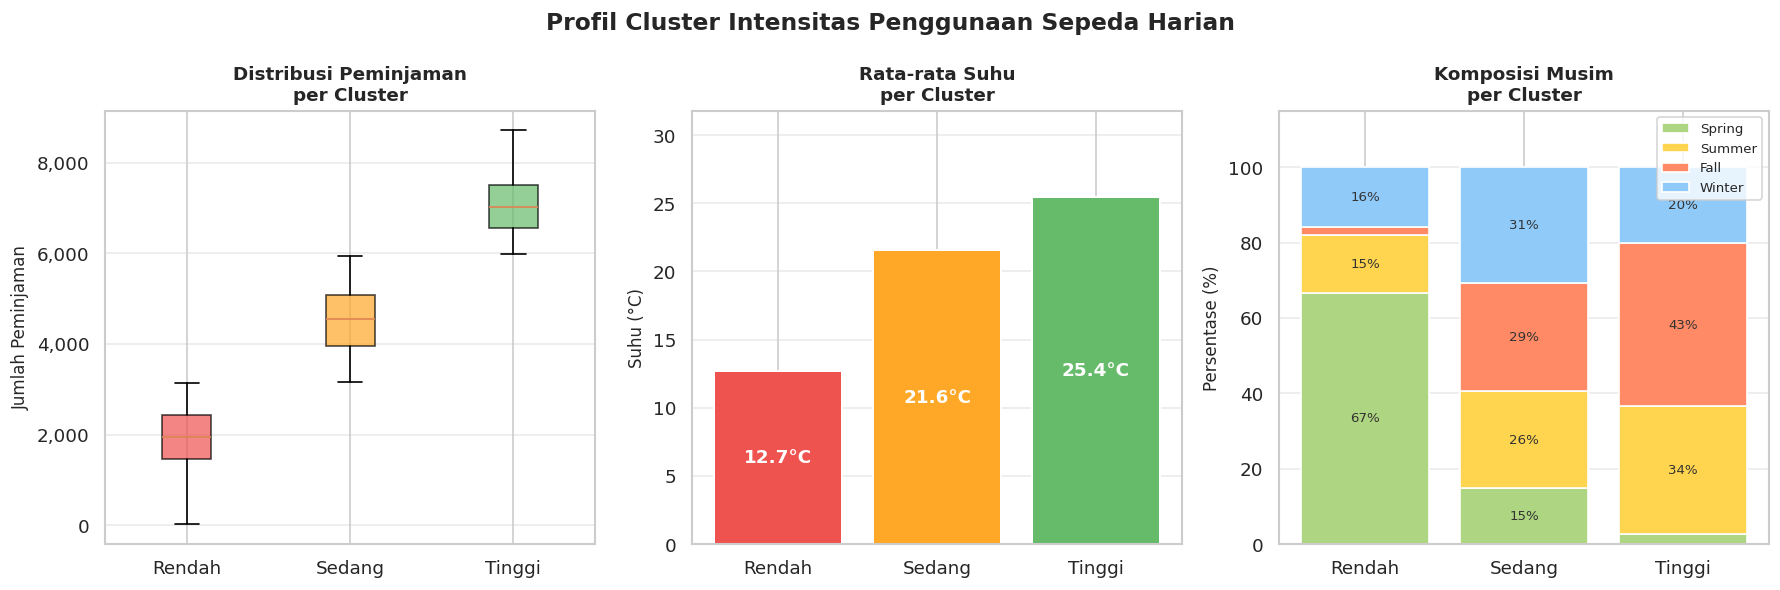

Visualisasi Clustering tersimpan.


In [24]:
cluster_order  = ['Rendah', 'Sedang', 'Tinggi']
cluster_colors = {'Rendah': '#EF5350', 'Sedang': '#FFA726', 'Tinggi': '#66BB6A'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Profil Cluster Intensitas Penggunaan Sepeda Harian', fontsize=14, fontweight='bold')

# Panel 1: Boxplot distribusi cnt per cluster
ax1 = axes[0]
data_by_cluster = [day_df[day_df['usage_cluster'] == c]['cnt'].values for c in cluster_order]
bp = ax1.boxplot(data_by_cluster, labels=cluster_order, patch_artist=True)
for patch, cluster in zip(bp['boxes'], cluster_order):
    patch.set_facecolor(cluster_colors[cluster])
    patch.set_alpha(0.7)
ax1.set_title('Distribusi Peminjaman\nper Cluster', fontsize=11, fontweight='bold')
ax1.set_ylabel('Jumlah Peminjaman', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.4)

# Panel 2: Bar chart rata-rata suhu per cluster
ax2 = axes[1]
temps = [cluster_profile.loc[c, 'rata_suhu'] for c in cluster_order]
bars2 = ax2.bar(cluster_order, temps, color=[cluster_colors[c] for c in cluster_order],
                edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, temps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'{val:.1f}°C', ha='center', va='center', fontsize=11, color='white', fontweight='bold')
ax2.set_title('Rata-rata Suhu\nper Cluster', fontsize=11, fontweight='bold')
ax2.set_ylabel('Suhu (°C)', fontsize=10)
ax2.set_ylim(0, max(temps) * 1.25)
ax2.grid(axis='y', alpha=0.4)

# Panel 3: Stacked bar komposisi musim per cluster
ax3 = axes[2]
season_pct = season_cluster.reindex(['Rendah','Sedang','Tinggi'])
season_cols_avail = [c for c in ['Spring','Summer','Fall','Winter'] if c in season_pct.columns]
season_colors_map = {'Spring':'#AED581','Summer':'#FFD54F','Fall':'#FF8A65','Winter':'#90CAF9'}
bottom = np.zeros(3)
for season in season_cols_avail:
    vals = season_pct[season].values
    ax3.bar(cluster_order, vals, bottom=bottom, label=season,
            color=season_colors_map.get(season,'gray'), edgecolor='white')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax3.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='#333')
    bottom += vals
ax3.set_title('Komposisi Musim\nper Cluster', fontsize=11, fontweight='bold')
ax3.set_ylabel('Persentase (%)', fontsize=10)
ax3.legend(loc='upper right', fontsize=8)
ax3.set_ylim(0, 115)
ax3.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('visualisasi_clustering.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Clustering tersimpan.')

**Insight Analisis Lanjutan:**
- Cluster **Tinggi** didominasi musim Fall dan Summer dengan rata-rata suhu tertinggi (~23°C) — cuaca hangat menjadi pendorong utama penggunaan sepeda.
- Cluster **Rendah** didominasi musim Spring dan Winter dengan rata-rata suhu terendah — cuaca dingin menjadi faktor penghambat utama.
- Cluster **Sedang** memiliki komposisi musim yang lebih merata, menunjukkan faktor lain seperti kelembaban dan hari libur turut berperan.
- Temuan ini berguna untuk perencanaan operasional seperti menyesuaikan jumlah armada sepeda berdasarkan musim dan prakiraan cuaca.

## Conclusion

- **Conclusion Pertanyaan 1:** Peminjaman sepeda harian mencapai puncak tertinggi pada musim **Fall (Gugur)** dengan kondisi cuaca **cerah atau sebagian berawan**, sementara titik terendah terjadi pada musim **Spring (Semi)** dengan cuaca **hujan atau salju ringan**. Pola ini menunjukkan bahwa faktor cuaca dan musim memiliki pengaruh signifikan terhadap keputusan pengguna untuk meminjam sepeda. Implikasinya, pengelola sistem bike-sharing sebaiknya meningkatkan kapasitas layanan pada musim gugur-panas dan bersiap menghadapi penurunan permintaan signifikan di musim semi atau saat cuaca buruk.

- **Conclusion Pertanyaan 2:** Terdapat perbedaan pola aktivitas yang jelas antara pengguna kasual dan terdaftar, serta antara hari kerja dan hari libur. Pengguna **terdaftar** pada hari kerja mengikuti pola komuter (puncak pagi dan sore), sedangkan pada hari libur beralih ke pola rekreasi (puncak siang). Pengguna **kasual** konsisten aktif di siang hari tanpa membedakan jenis hari. Temuan ini menyarankan bahwa strategi promosi sebaiknya dibedakan: pengguna terdaftar lebih tepat disasar dengan program komuter, sementara pengguna kasual lebih cocok dengan promosi wisata atau paket akhir pekan.